In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

In [3]:
def generate_sequence(seq_length=5, num_samples=1000):
  X,y=[],[]
  for _ in range(num_samples):
    seq = np.random.rand(seq_length)
    X.append(seq)
    y.append(seq[-1]+0.1)
  return np.array(X), np.array(y)

In [4]:
seq_length = 5

In [5]:
X,y = generate_sequence(seq_length)

In [19]:
split=int(0.8*len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[:split], y[:split]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [24]:
model = Sequential([
    SimpleRNN(10, activation='relu', input_shape=(seq_length,1)),
    Dense(1)
])

In [25]:
model.compile(optimizer='adam', loss='mse')

In [26]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6583 - val_loss: 0.5419
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4582 - val_loss: 0.3756
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2513 - val_loss: 0.1124
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0804 - val_loss: 0.0562
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0432 - val_loss: 0.0327
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0255 - val_loss: 0.0181
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0140 - val_loss: 0.0096
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - val_loss: 0.0050
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - val_loss: 7.9223e-04
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7028e-04 

In [29]:
test_loss=model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0438e-05 
Test Loss: 4.0438240830553696e-05


In [31]:
sample_output = np.array([0.1,0.2,0.3,0.4,0.5]).reshape(1, seq_length,1)
predicted_value = model.predict(sample_output)
print(f"Predicted next value: {predicted_value}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted next value: [[0.60231483]]


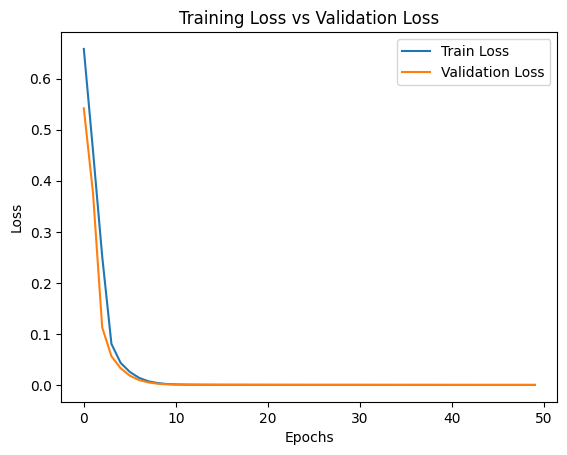

In [32]:
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training Loss vs Validation Loss")
plt.show()